**1. Import libraries**

In [1]:
#Import libraries
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import string

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

**2. Create an array of images and a list of labels (filename without extension)**

In [2]:
data_dir = 'drive/MyDrive/Colab Notebooks/DEEP LEARNING/CNN/samples'

images = []
labels = []

for filename in os.listdir(data_dir):
    if filename.endswith(".png"):
        img_path = os.path.join(data_dir, filename)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (200, 50))  #Redim
        images.append(img)
        labels.append(filename.split('.')[0])  #Filename without extension

images,labels= np.array(images), np.array(labels)
TOTAL_IMAGES=len(images)

**3. Review image features and visualize it**


(50, 200, 3)
Height:  50
Width:  200
Channels:  3
Type:  uint8


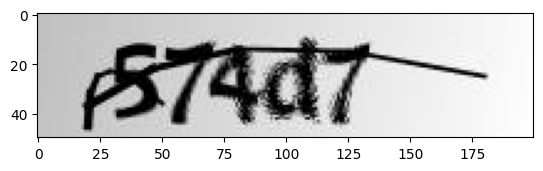

In [3]:
#Features of an image
rand_image=65
IMG_HEIGHT=images[rand_image].shape[0]
IMG_WIDTH=images[rand_image].shape[1]
IMG_CHANNELS=images[rand_image].shape[2]

print(images[rand_image].shape)

print("Height: ",images[rand_image].shape[0])
print("Width: ",images[rand_image].shape[1])
print("Channels: ",images[rand_image].shape[2])
print("Type: ",images[rand_image].dtype)

plt.imshow(images[rand_image])

#We can see the color mode of the image is RGB, so we will require to use at least 3 channels
#-Grayscale - 1 channel
#-RGB - 3 channels

**4. Preprocess images (Normalize)**

In [4]:
images_preprocess=[]
for img in images:
  img=img/255
  images_preprocess.append(img)

images_scaled=np.array(images_preprocess)

# print(images_scaled[rand_image])
print(images_scaled.shape)


(1040, 50, 200, 3)


**5. Labels Encoding**

In [5]:
#Converts labels(file names) into a form that the model can use.
#This involves creating a mapping from characters to indexes and vice versa

CHARACTER_SET = 'abcdefghijklmnopqrstuvwxyz0123456789'
CHARACTER_COUNT = len(CHARACTER_SET)

char_to_int = {char: index for index, char in enumerate(CHARACTER_SET)}
int_to_char = {index: char for index, char in enumerate(CHARACTER_SET)}

one_hot_labels=[]
for label in labels:
  one_hot_list=[]
  for char in label:
      one_hot_array = np.zeros(CHARACTER_COUNT, dtype=int)
      index = char_to_int[char]
      one_hot_array[index] = 1
      one_hot_list.append(one_hot_array)
  one_hot_labels.append(one_hot_list)

encoded_labels=np.array(one_hot_labels)
print(encoded_labels.shape)

print(encoded_labels[rand_image])


# encoded_labels = []
# for label in labels:
#   encoded = [char_to_int[c] for c in label]
#   encoded_labels.append(encoded)

# encoded_labels= np.array(encoded_labels)
# print(encoded_labels[rand_image])

# chars=[CHARACTER_SET[i] for i in encoded_labels[rand_image]]
# print(chars)

(1040, 5, 36)
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]]


**6. Creation of sets for training and testing**

(832, 50, 200, 3)
(208, 50, 200, 3)
(832, 5, 36)
(208, 5, 36)
[[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0]]


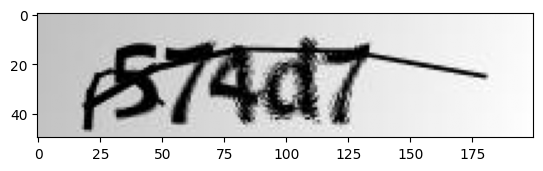

In [6]:
# X_train, X_test, y_train, y_test = train_test_split(images_scaled, encoded_labels, test_size=0.2)

X_train = images_scaled[0:int(TOTAL_IMAGES*.8),:]
X_test = images_scaled[int(TOTAL_IMAGES*.8):,:]

y_train = encoded_labels[0:int(TOTAL_IMAGES*.8),:]
y_test = encoded_labels[int(TOTAL_IMAGES*.8):,:]

X_train = X_train.reshape(-1, IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)
X_test = X_test.reshape(-1, IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

print(y_train[rand_image])
# chars=[CHARACTER_SET[i] for i in y_train[rand_image]]
# print(chars)

plt.imshow(X_train[rand_image])

**7. Include Image augmentation to improve the model**

In [ ]:
datagen = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False,
)


**8. Model Creation - CNN**

In [18]:
#Original Model
input = layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))

x = layers.Conv2D(32, (3, 3), activation='relu')(input)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(64, (3, 3), activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(128, (3, 3), activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Conv2D(256, (3, 3), activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2))(x)

x = layers.Flatten()(x)

x = layers.Dense(128, activation='relu')(x)
x = layers.Reshape((-1, 128))(x)
x = layers.LSTM(128, return_sequences=True)(x)

output = layers.Dense(5*CHARACTER_COUNT , activation='softmax')(x)
output = layers.Reshape((5,CHARACTER_COUNT))(output)

model = keras.Model(inputs=input, outputs=output)
model.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()



Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)          │ (None, 50, 200, 3)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_40 (Conv2D)                   │ (None, 48, 198, 32)         │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_40               │ (None, 48, 198, 32)         │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_40 (MaxPooling2D)      │ (None, 24, 99, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_41 (Conv2D)                   │ (None, 22, 97, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_41               │ (None, 22, 97, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_41 (MaxPooling2D)      │ (None, 11, 48, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_42 (Conv2D)                   │ (None, 9, 46, 128)          │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_42               │ (None, 9, 46, 128)          │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_42 (MaxPooling2D)      │ (None, 4, 23, 128)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_43 (Conv2D)                   │ (None, 2, 21, 256)          │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_43               │ (None, 2, 21, 256)          │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_43 (MaxPooling2D)      │ (None, 1, 10, 256)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_10 (Flatten)                 │ (None, 2560)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 128)                 │         327,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_11 (Reshape)                 │ (None, 1, 128)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_10 (LSTM)                       │ (None, 1, 128)              │         131,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 1, 180)              │          23,220 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape_12 (Reshape)                 │ (None, 5, 36)               │               0 │
└──────────────────────────────────────┴─────────────────────────────┴──────────────

 Total params: 872,948 (3.33 MB)

 Trainable params: 871,988 (3.33 MB)

 Non-trainable params: 960 (3.75 KB)

**9. Model Training**

In [20]:
#Use callbacks to save the best model and stop training if it doesn't improve
# early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
# model_checkpoint = ModelCheckpoint('best_model.keras', save_best_only=True)

history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.0653 - loss: 3.3943 - val_accuracy: 0.0375 - val_loss: 3.5585
Epoch 2/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 37s 1s/step - accuracy: 0.1186 - loss: 2.8988 - val_accuracy: 0.0500 - val_loss: 3.5290
Epoch 3/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.2115 - loss: 2.6620 - val_accuracy: 0.0548 - val_loss: 3.5177
Epoch 4/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.3264 - loss: 2.4651 - val_accuracy: 0.0490 - val_loss: 3.4730
Epoch 5/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.4317 - loss: 2.2648 - val_accuracy: 0.0548 - val_loss: 3.3807
Epoch 6/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.5423 - loss: 2.0454 - val_accuracy: 0.0971 - val_loss: 3.3839
Epoch 7/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 40s 1s/step - accuracy: 0.6405 - loss: 1.8281 - val_accuracy: 0.0885 - val_loss: 3.2971
Epoch 8/20
26/26 ━━━━━━━━━━━━━━━━━━━━ 32s 1s/step - accuracy: 0.7158 - loss: 1.6395 - val_accuracy: 0.0904 - val_loss:

**9. Evaluate the Model**

In [21]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f'Loss: {test_loss}, Accuracy: {test_accuracy}')

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 234ms/step - accuracy: 0.5590 - loss: 2.2182
Loss: 2.1761224269866943, Accuracy: 0.5836538672447205


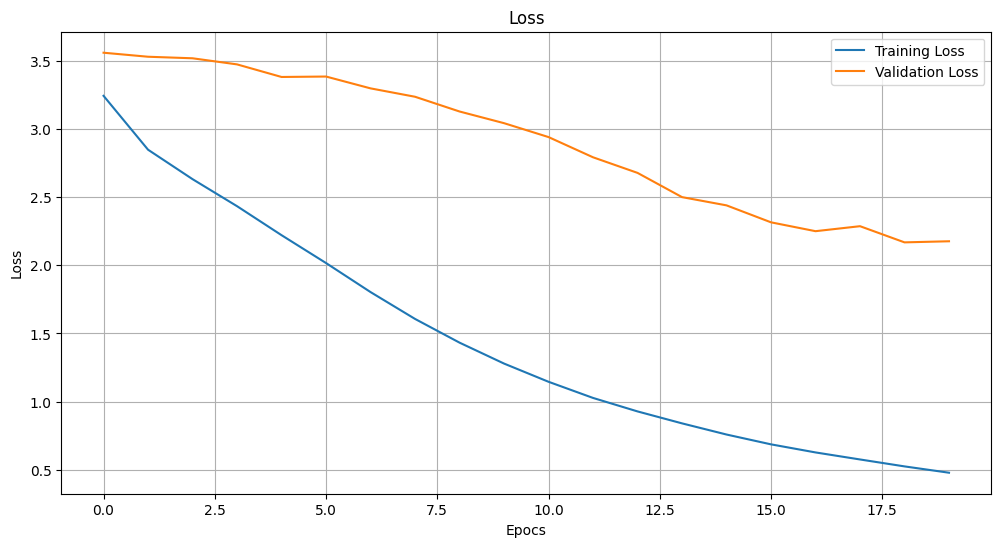

In [22]:
#Loss
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epocs')
plt.ylabel('Loss')
plt.legend()
plt.grid()
plt.show()

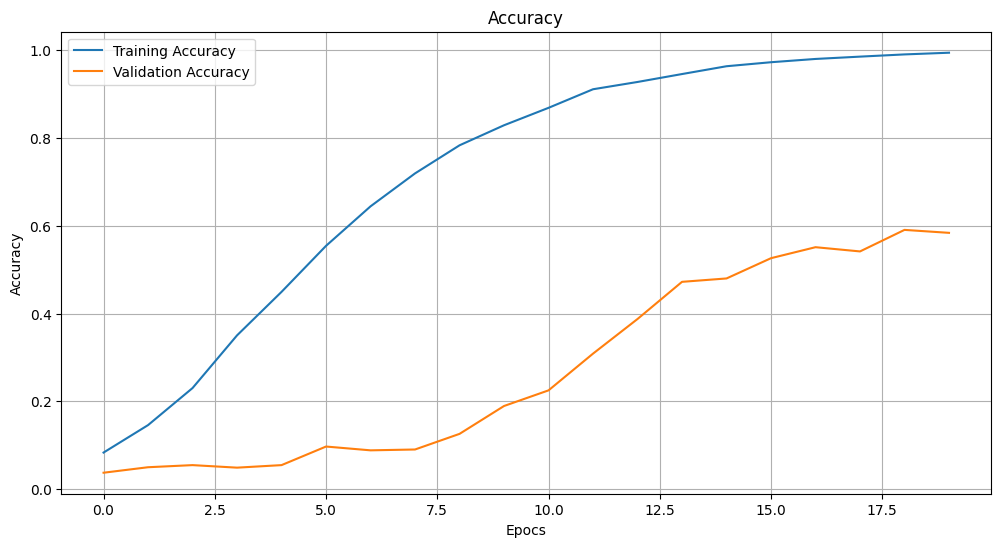

In [23]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epocs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid()
plt.show()

**10. Predictions**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step
Captcha predicted:  efgxb
Captcha real:  43p5d


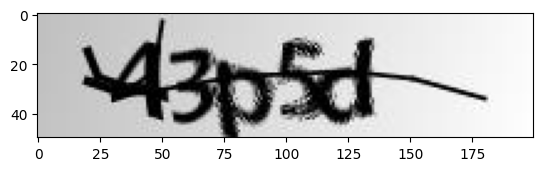

In [24]:
rand_image=55
img = np.expand_dims(X_test[rand_image], axis=0)

predictions = model.predict(img)
predicted_classes = np.argmax(predictions, axis=-1)
predicted_chars = [CHARACTER_SET[i] for i in predicted_classes[0]]

captcha=''.join(predicted_chars)
print("Captcha predicted: ", captcha)
print("Captcha real: ",labels[rand_image])

plt.imshow(images[rand_image])